In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_datareader as data
import yfinance as yf


In [3]:
start = '2012-01-01'
end = '2022-12-21'

df = yf.download('TSLA', start=start, end=end)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2012-01-03,1.872000,1.966667,1.843333,1.929333,13921500
2012-01-04,1.847333,1.911333,1.833333,1.880667,9451500
2012-01-05,1.808000,1.862000,1.790000,1.850667,15082500
2012-01-06,1.794000,1.852667,1.760667,1.813333,14794500
2012-01-09,1.816667,1.832667,1.741333,1.800000,13455000


In [4]:
df.head()


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2012-01-03,1.872000,1.966667,1.843333,1.929333,13921500
2012-01-04,1.847333,1.911333,1.833333,1.880667,9451500
2012-01-05,1.808000,1.862000,1.790000,1.850667,15082500
2012-01-06,1.794000,1.852667,1.760667,1.813333,14794500
2012-01-09,1.816667,1.832667,1.741333,1.800000,13455000


In [5]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2022-12-14,156.800003,161.619995,155.309998,159.250000,140682300
2022-12-15,157.669998,160.929993,153.279999,153.440002,122334500
2022-12-16,150.229996,160.990005,150.039993,159.639999,139032200
2022-12-19,149.869995,155.250000,145.820007,154.000000,139390600
2022-12-20,137.800003,148.470001,137.660004,146.050003,159563300


In [6]:
df=df.reset_index()
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2012-01-03,1.872000,1.966667,1.843333,1.929333,13921500
1,2012-01-04,1.847333,1.911333,1.833333,1.880667,9451500
2,2012-01-05,1.808000,1.862000,1.790000,1.850667,15082500
3,2012-01-06,1.794000,1.852667,1.760667,1.813333,14794500
4,2012-01-09,1.816667,1.832667,1.741333,1.800000,13455000


In [7]:
df=df.drop(['High'],axis=1)

C:\Users\AJAY BHOLA\AppData\Local\Temp\ipykernel_13452\3415488251.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df=df.drop(['High'],axis=1)


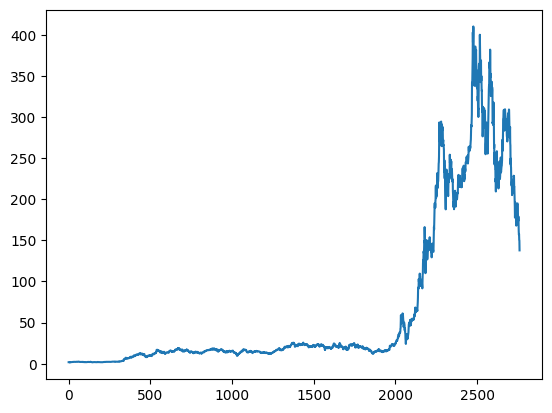

In [8]:
plt.plot(df.Close)

In [9]:
df

Price,Date,Close,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA
0,2012-01-03,1.872000,1.843333,1.929333,13921500
1,2012-01-04,1.847333,1.833333,1.880667,9451500
2,2012-01-05,1.808000,1.790000,1.850667,15082500
3,2012-01-06,1.794000,1.760667,1.813333,14794500
4,2012-01-09,1.816667,1.741333,1.800000,13455000
...,...,...,...,...,...
2756,2022-12-14,156.800003,155.309998,159.250000,140682300
2757,2022-12-15,157.669998,153.279999,153.440002,122334500
2758,2022-12-16,150.229996,150.039993,159.639999,139032200


In [10]:
ma100=df.Close.rolling(100).mean()
ma100

Ticker,TSLA
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2756,244.372967
2757,243.361068
2758,242.115167
2759,240.804867


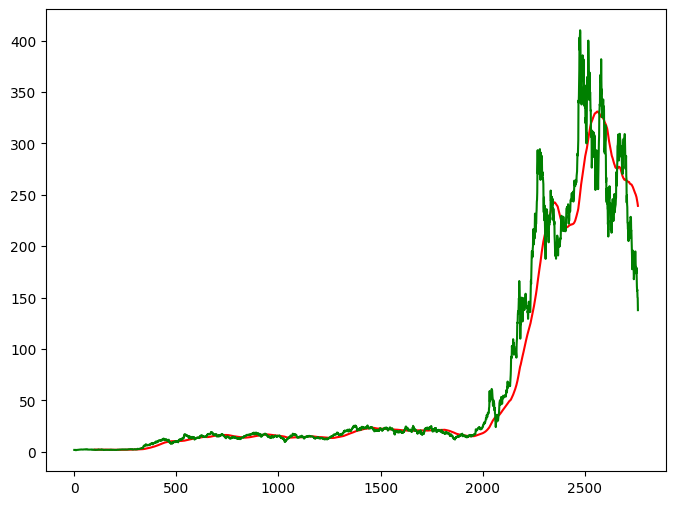

In [11]:
plt.figure(figsize=(8,6))
plt.plot(ma100, 'r')
plt.plot(df.Close, 'g')
plt.show()

In [12]:
ma200 = df.Close.rolling(200).mean()
ma200

Ticker,TSLA
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2756,259.995317
2757,259.317184
2758,258.669517
2759,258.021717


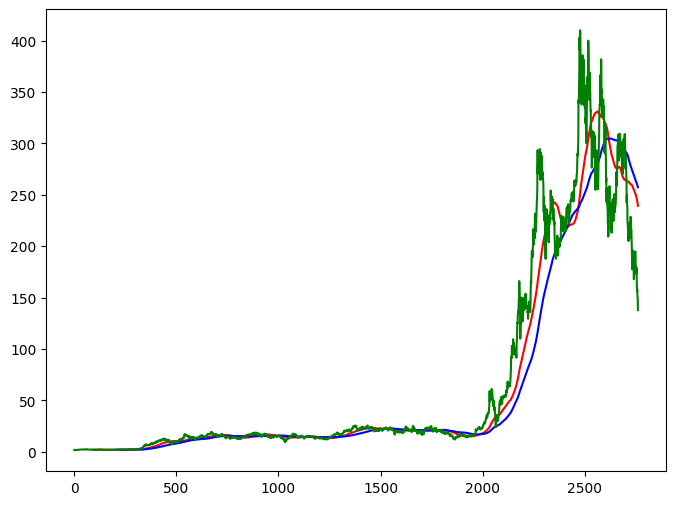

In [13]:
plt.figure(figsize=(8,6))
plt.plot(ma100, 'r')
plt.plot(ma200,'b')
plt.plot(df.Close,'g')
plt.show()

In [14]:
df.shape

(2761, 5)

In [15]:
data.dropna(inplace=True)

AttributeError: module 'pandas_datareader' has no attribute 'dropna'

In [16]:
data_train = pd.DataFrame(df.Close[0: int(len(df)*0.80)])
data_test = pd.DataFrame(df.Close[int(len(df)*0.80): len(df)])

In [17]:
data_train.shape[0]

2208

In [18]:
data_test.shape[0]

553

In [19]:
data_train.head()

Ticker,TSLA
0,1.872000
1,1.847333
2,1.808000
3,1.794000
4,1.816667


In [20]:
data_test.head()

Ticker,TSLA
2208,147.433334
2209,148.883331
2210,153.766663
2211,149.626663
2212,146.556671


In [21]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [22]:
data_train_array = scaler.fit_transform(data_train)
data_train_array

array([[0.00214273],
       [0.00199286],
       [0.00175388],
       ...,
       [0.85211492],
       [0.85337058],
       [0.8697348 ]])

In [24]:
x = []
y = []

for i in range(100, data_train_array.shape[0]):
    x.append(data_train_array[i-100:i])
    y.append(data_train_array[i,0])


In [25]:
x, y = np.array(x), np.array(y)

In [26]:
from keras.layers import Dense, Dropout, LSTM, Input
from keras.models import Sequential

In [27]:
model = Sequential()
model.add(Input(shape=(x.shape[1], 1)))

model.add(LSTM(units=50, activation='relu', return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=60, activation='relu', return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=80, activation='relu', return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units=120, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1))

In [28]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [29]:
model.fit(x,y, epochs = 50, batch_size =32, verbose =1)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 396ms/step - loss: 0.0078
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 342ms/step - loss: 0.0026
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 42s 351ms/step - loss: 0.0019
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 41s 352ms/step - loss: 0.0017
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 78s 914ms/step - loss: 0.0020
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 25s 381ms/step - loss: 0.0020
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 39s 356ms/step - loss: 0.0018
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 28s 418ms/step - loss: 0.0014
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 27s 411ms/step - loss: 0.0016
Epoch 10/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 36s 344ms/step - loss: 0.0015
Epoch 11/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 27s 406ms/step - loss: 0.0015
Epoch 12/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - loss: 0.0014
Epoch 13/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 28s 339ms/step - loss: 0.0015
Epoch 14/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 25s 374ms/step - loss: 0.0013
Epoch 15/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 27s 41

In [31]:
model.save('Model_keras.h5')

In [32]:
data_test.head()

Ticker,TSLA
2208,147.433334
2209,148.883331
2210,153.766663
2211,149.626663
2212,146.556671


In [33]:
pas_100_days = data_train.tail(100)

In [35]:
final_df = pd.concat([pas_100_days, data_test], ignore_index=True)

In [36]:
final_df.head()

Ticker,TSLA
0,54.370667
1,55.173332
2,54.458668
3,54.591331
4,54.681999


In [37]:
input_data  =  scaler.fit_transform(final_df)
input_data

array([[0.00182456],
       [0.00407766],
       [0.00207158],
       [0.00244397],
       [0.00269848],
       [0.        ],
       [0.00546246],
       [0.01727067],
       [0.01417546],
       [0.01443744],
       [0.01096048],
       [0.01494271],
       [0.026968  ],
       [0.025237  ],
       [0.04102745],
       [0.03125714],
       [0.02422835],
       [0.03463678],
       [0.03299561],
       [0.03480333],
       [0.03708076],
       [0.03650814],
       [0.03527679],
       [0.03667281],
       [0.02901337],
       [0.03371609],
       [0.02880566],
       [0.03808942],
       [0.05127495],
       [0.05872665],
       [0.07538726],
       [0.10587528],
       [0.10929611],
       [0.10480862],
       [0.11012325],
       [0.13826272],
       [0.12935696],
       [0.13305101],
       [0.1385172 ],
       [0.1300269 ],
       [0.13006433],
       [0.15666742],
       [0.14269968],
       [0.1471853 ],
       [0.13235298],
       [0.11437495],
       [0.13731768],
       [0.125

In [38]:
input_data.shape

(653, 1)

In [41]:
x = []
y = []

for i in range(100, input_data.shape[0]):
    x.append(input_data[i-100:i])
    y.append(input_data[i,0])
x, y = np.array(x), np.array(y)

In [42]:
x.shape
y.shape

(553,)

In [43]:
y_predict = model.predict(x)

18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step


In [44]:
y_predict.shape

(553, 1)

In [45]:
y

array([0.26305359, 0.26712376, 0.28083139, 0.26921031, 0.26059278,
       0.2523214 , 0.24400326, 0.24465824, 0.24760558, 0.24277754,
       0.24245005, 0.246567  , 0.22910731, 0.2336079 , 0.21228389,
       0.22395174, 0.24583719, 0.24310499, 0.25911439, 0.25149801,
       0.24336699, 0.23316815, 0.23950267, 0.23447807, 0.23142781,
       0.23104417, 0.26240799, 0.30454138, 0.31635897, 0.30732035,
       0.33748647, 0.36885962, 0.38628187, 0.3972854 , 0.38029356,
       0.39634974, 0.38143512, 0.40441526, 0.40971115, 0.44968317,
       0.45728084, 0.41480124, 0.43593811, 0.41995681, 0.44787734,
       0.44172057, 0.43191471, 0.4629136 , 0.49949849, 0.45726212,
       0.44835453, 0.4536317 , 0.46840601, 0.4702025 , 0.47235458,
       0.49929264, 0.5094821 , 0.53203187, 0.53702837, 0.55655589,
       0.6127525 , 0.67261692, 0.60821447, 0.64400401, 0.64865434,
       0.63984959, 0.62222149, 0.63942855, 0.64494905, 0.63984025,
       0.64138408, 0.67334677, 0.67548947, 0.65777717, 0.63089

In [46]:
y_predict

array([[0.24086195],
       [0.24190974],
       [0.24376903],
       [0.24695054],
       [0.25116095],
       [0.25547296],
       [0.25872055],
       [0.25986525],
       [0.25859562],
       [0.25525433],
       [0.25038   ],
       [0.24465019],
       [0.23889397],
       [0.23338605],
       [0.22841048],
       [0.22362468],
       [0.21910831],
       [0.21575165],
       [0.2142362 ],
       [0.21526262],
       [0.21880071],
       [0.22408399],
       [0.22974758],
       [0.23480117],
       [0.2384775 ],
       [0.24031296],
       [0.24025789],
       [0.23943199],
       [0.24014394],
       [0.24432422],
       [0.25232238],
       [0.26416755],
       [0.27985623],
       [0.29898262],
       [0.32048786],
       [0.3420176 ],
       [0.3616386 ],
       [0.37714612],
       [0.38804787],
       [0.39475858],
       [0.39952743],
       [0.40424162],
       [0.4080978 ],
       [0.4107759 ],
       [0.41152668],
       [0.4110486 ],
       [0.40991747],
       [0.408

In [48]:
scaler.scale_

array([0.00280702])

In [51]:
scale_factor=1/0.0280702
y_predict=y_predict*scale_factor
y=y*scale_factor

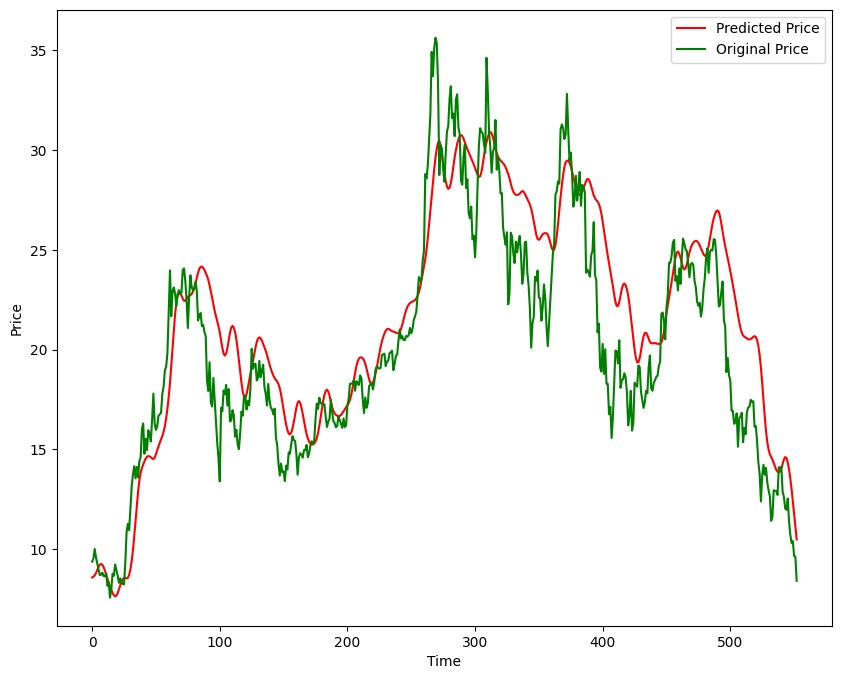

In [52]:
plt.figure(figsize=(10,8))
plt.plot(y_predict, 'r', label = 'Predicted Price')
plt.plot(y, 'g', label = 'Original Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()